# Extrapolate Compute
We extrapolate
$$\begin{align*}
    \mathbb{E}[\text{runtime on first c configs with first s seed combinations}] &= \mathbb{E}\left[\sum_{\text{workflow}}\sum_\mathit{D}\sum_{\text{seed combination}}\text{ runtime of first c configs of workflow on }\mathit{D}\text{ and seed combination}\right]\\
    &= \sum_{\text{workflow}}\sum_\mathit{D}\sum_{\text{seed combination}}\mathbb{E}\left[\text{ runtime of first c configs of workflow $w$ on }\mathit{D}\text{ and seed combination}\right]\\
    &\approx |\text{\# seed combinations}| \cdot\sum_{\text{workflow}}\sum_\mathit{D}\mathbb{E}\left[\text{ runtime of first c configs of workflow $w$ on }\mathit{D}\text{ and any seed combination}\right]\\
    &\approx c\cdot |\text{\# seed combinations}| \cdot\sum_{\text{workflow}}\sum_\mathit{D}\mathbb{E}\left[\text{any config of workflow $w$ on }\mathit{D}\text{ and any seed combination}\right]
\end{align*}
$$
Here we assume that the expected runtime is the same across seeds, which is reasonable.

# Algorithm to determine the Profile

**Inputs**: 
- minimum number of parallel tasks
- confidence that node will not be mem-killed (this confidence must hold for *every* workflow/dataset combination, not in average)
- confidence that a single task will not be mem-killed (this confidence must hold for *every* workflow/dataset combination, not in average)

**Algorithm**:
1. check whether we can securely avoid a node kill under full node parallelization (one config for each CPU); this is based on the upper memory bound * number of CPUs
2. if not, check whether we can likely (based on probabilities) avoid a node kill under full node parallelization (one config for each CPU); this is based on sampling
3. if not, find the maximum number of parallel tasks that can be executed in parallel that avoids node kill (given the task memory limit)
4. if this number if below the desired parallelization of tasks, run a new optimization where we find the *biggest* task memory limit that will avoid node kill (given the number of parallel jobs)

**Output for each workflow/dataset**:
- number of parallel tasks (always at least the minimum desired)
- memory limit per task
- confidence of no task memory kill
- confidence of no node kill

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from lcdb.db._results import ResultSet
from lcdb.inspection import ResourceUsageVisualizer

In [2]:
rs = ResultSet.concat([
    ResultSet.read_jsonl(f"../surf/snellius/data/{k}.jsonl")
    for k in [
        "lcdb.workflow.sklearn.KNNWorkflow",
        "lcdb.workflow.sklearn.LibLinearWorkflow",
        #"lcdb.workflow.sklearn.LibSVMWorkflow",
        #"lcdb.workflow.sklearn.TreesEnsembleWorkflow",
        #"lcdb.workflow.xgboost.XGBoostWorkflow",
        # "lcdb.workflow.keras.DenseNNWorkflow"
    ]
])

In [ ]:
ruv = ResourceUsageVisualizer(result_set=rs)
ruv.plot_kill_rates_as_function_of_task_memory_limit()
ruv.plot_memory_consumption()
ruv.plot_memory_vs_runtimes()
ruv.plot_boxplots_of_runtimes_per_workflow_and_dataset()
ruv.plot_accumulated_memory_usage_over_time()
ruv.plot_anticipated_memory_requirements()
ruv.plot_empirically_observed_memory_consumption_over_time()

In [49]:
for min_num_parallel_tasks in [2, 4, 8, 16]:
    for absolute_max_memory_limit_per_task in [1, 4, 16, 32, 64]:
        for confidence_of_no_config_kill in [0.75, 0.85, 0.9, 0.95]:
            used_profile = re.approximate_parallel_tasks_based_on_sampling(
                min_num_parallel_tasks=min_num_parallel_tasks,
                max_num_parallel_tasks=192,
                absolute_max_memory_limit_per_task=absolute_max_memory_limit_per_task,
                sample_size=10**2,
                confidence_of_no_node_kill=0.999,
                confidence_of_no_config_kill=confidence_of_no_config_kill
            )

TypeError: ResourceEstimator.__init__() got an unexpected keyword argument 'min_num_parallel_tasks'

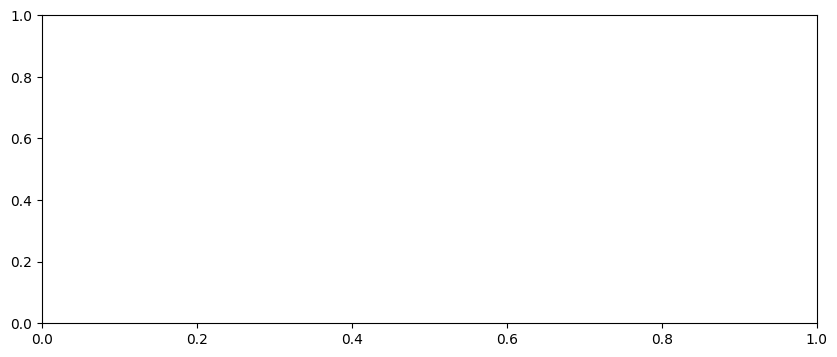

In [36]:
def get_surf_table(
        df_node_runtimes_per_config,
        num_configs,
        max_cpu_cores_in_node,
        num_seed_combinations,
        num_datasets=None # this is usually automatically inferred unless one wants to decouple the forecast from the empirical data
    ):
    
    # now create the final summary table
    rows = []
    
    for workflow, sub_df in df_node_runtimes_per_config.groupby("workflow"):

        # for each dataset, we have an upper bound for the walltime per config.
        # since each config/dataset combination is one step, we take the mean across datasets
        walltime_per_seed_combination_on_this_workflow_dataset_combo = np.round(sub_df["upper_node_hours_per_config"].mean(), 4)
        
        num_datasets_used_for_estimation = len(sub_df["openmlid"].unique())
        if num_datasets is None:
            num_datasets = num_datasets_used_for_estimation

        # get kill rates
        avg_kill_rate_across_datasets = np.round(sub_df["expected_kill_rate"].mean(), 4)
        q90_kill_rate_across_datasets = np.round(sub_df["expected_kill_rate"].quantile(0.9), 4)
        max_kill_rate_across_datasets = np.round(sub_df["expected_kill_rate"].max(), 4)

        rows.append([
            workflow,
            num_datasets_used_for_estimation,
            np.round(np.mean([sub_df["num_configs_used_for_estimation"]]), 2),
            num_seed_combinations, # number of runs: in our case one run is to execute the number of configs once on all datasets
            num_datasets * num_configs, # number of steps: in our case this is the number of datasets * number of configs
            walltime_per_seed_combination_on_this_workflow_dataset_combo, # walltime per step
            max_cpu_cores_in_node, # CPU cores
            0, # GPUs,
            1, # accounting weight
            avg_kill_rate_across_datasets,
            q90_kill_rate_across_datasets,
            max_kill_rate_across_datasets
        ])
    
    df = pd.DataFrame(rows, columns=["Type Run", "Datasets Used for Estimate", "Avg Configs per Dataset Used For Estimate", "# Runs", "# Steps per Run", "Walltime per Step", "# CPU cores", " GPUs", "Accounting Weight", "Average Kill Rate", "q90 Kill Rate", "Max Kill Rate"])
    df["Total SBUs (in millions)"] = np.round((df["# Runs"] * df["# Steps per Run"] * df["Walltime per Step"] * df["# CPU cores"] * df["Accounting Weight"]) / 10**6, 2)
    return df

# example for one random profile
df_node_runtimes_per_config = re.get_node_hours_per_config_for_profile(
    task_parallelization_profile=list(re.profiles.keys())[-1],
    max_cpu_cores_in_node=192,
    std_deviations_for_upper_bound=3
)
df_node_runtimes_per_config.sort_values("num_parallel_tasks")
get_surf_table(
    df_node_runtimes_per_config=df_node_runtimes_per_config,
    num_datasets=51,
    num_configs=10**4,
    max_cpu_cores_in_node=192,
    num_seed_combinations=25
)

,Type Run,Datasets Used for Estimate,Avg Configs per Dataset Used For Estimate,# Runs,# Steps per Run,Walltime per Step,# CPU cores,GPUs,Accounting Weight,Average Kill Rate,q90 Kill Rate,Max Kill Rate,Total SBUs (in millions)
0,lcdb.workflow.sklearn.KNNWorkflow,69,497.10,25,510000,0.0063,192,0,1,0.0343,0.0700,0.154,15.42
1,lcdb.workflow.sklearn.LibLinearWorkflow,67,479.10,25,510000,0.0075,192,0,1,0.0356,0.0508,0.225,18.36
2,lcdb.workflow.sklearn.LibSVMWorkflow,68,474.71,25,510000,0.0044,192,0,1,0.0298,0.0500,0.106,10.77
3,lcdb.workflow.sklearn.TreesEnsembleWorkflow,53,500.00,25,510000,0.0075,192,0,1,0.0263,0.0500,0.076,18.36
4,lcdb.workflow.xgboost.XGBoostWorkflow,53,500.00,25,510000,0.0079,192,0,1,0.0216,0.0500,0.078,19.34


# Effect of the Per-Config Memory Limit

In [10]:
tables = []
for profile in re.profiles.keys():
        
    df_node_runtimes_per_config = re.get_node_hours_per_config_for_profile(
        task_parallelization_profile=profile,
        max_cpu_cores_in_node=192,
        std_deviations_for_upper_bound=3
    )
        
    table_for_budget = get_surf_table(
        df_node_runtimes_per_config=df_node_runtimes_per_config,
        num_datasets=51,
        num_configs=10**4,
        max_cpu_cores_in_node=192,
        num_seed_combinations=25
    )
    table_for_budget["min_num_parallel_tasks"] = min_num_parallel_tasks
    for k, v in re.profiles[profile]["decisions"].items():
        table_for_budget[k] = v
    tables.append(table_for_budget)

In [ ]:
df_all_options = pd.concat(tables, ignore_index=True)
df_all_options

,Type Run,Datasets Used for Estimate,Avg Configs per Dataset Used For Estimate,# Runs,# Steps per Run,Walltime per Step,# CPU cores,GPUs,Accounting Weight,Average Kill Rate,q90 Kill Rate,Max Kill Rate,Total SBUs (in millions),min_num_parallel_tasks,sample_size,max_num_parallel_tasks,absolute_max_memory_limit_per_task,confidence_of_no_node_kill,confidence_of_no_config_kill,importance_of_most_expensive_compared_to_cheapest
0,lcdb.workflow.sklearn.KNNWorkflow,69,497.10,25,510000,0.0011,192,0,1,0.4307,1.0000,1.000,2.69,2,100,192,1,0.999,0.75,2
1,lcdb.workflow.sklearn.LibLinearWorkflow,67,479.10,25,510000,0.0013,192,0,1,0.3365,1.0000,1.000,3.18,2,100,192,1,0.999,0.75,2
2,lcdb.workflow.sklearn.LibSVMWorkflow,68,474.71,25,510000,0.0011,192,0,1,0.4261,1.0000,1.000,2.69,2,100,192,1,0.999,0.75,2
3,lcdb.workflow.sklearn.TreesEnsembleWorkflow,53,500.00,25,510000,0.0017,192,0,1,0.3460,0.9992,1.000,4.16,2,100,192,1,0.999,0.75,2
4,lcdb.workflow.xgboost.XGBoostWorkflow,53,500.00,25,510000,0.0018,192,0,1,0.4015,1.0000,1.000,4.41,2,100,192,1,0.999,0.75,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,lcdb.workflow.sklearn.KNNWorkflow,69,497.10,25,510000,0.0063,192,0,1,0.0343,0.0700,0.154,15.42,16,100,192,64,0.999,0.95,2
396,lcdb.workflow.sklearn.LibLinearWorkflow,67,479.10,25,510000,0.0075,192,0,1,0.0356,0.0508,0.225,18.36,16,100,192,64,0.999,0.95,2
397,lcdb.workflow.sklearn.LibSVMWorkflow,68,474.71,25,510000,0.0044,192,0,1,0.0298,0.0500,0.106,10.77,16,100,192,64,0.999,0.95,2
398,lcdb.workflow.sklearn.TreesEnsembleWorkflow,53,500.00,25,510000,0.0075,192,0,1,0.0263,0.0500,0.076,18.36,16,100,192,64,0.999,0.95,2


In [35]:
choices = []
for (confidence_of_no_config_kill, absolute_max_memory_limit_per_task, min_num_parallel_tasks), df_option in df_all_options.groupby(["confidence_of_no_config_kill", "absolute_max_memory_limit_per_task", "min_num_parallel_tasks"]):
    total_sbus = df_option["Total SBUs (in millions)"].sum()
    is_valid = total_sbus <= 30
    if is_valid and df_option["Average Kill Rate"].max() < 0.2:
        choices.append(
            (min_num_parallel_tasks, absolute_max_memory_limit_per_task, confidence_of_no_config_kill, total_sbus, df_option["Average Kill Rate"].mean(), df_option["q90 Kill Rate"].mean(), df_option["Max Kill Rate"].mean())
        )

pd.DataFrame(choices, columns=["min parallel tasks", "task memory limit", "confidence no config kill", "SBUs", "avg kill rate", "q90 kill rate", "max kill rate"])

,min parallel tasks,task memory limit,confidence no config kill,SBUs,avg kill rate,q90 kill rate,max kill rate
0,2,4,0.75,22.53,0.12010,0.25000,0.2500
1,4,4,0.75,22.53,0.12004,0.25000,0.2500
2,8,4,0.75,22.53,0.11972,0.25000,0.2500
3,16,4,0.75,22.29,0.12004,0.25000,0.2500
4,2,16,0.75,28.64,0.13414,0.25000,0.2500
5,4,16,0.75,28.64,0.13320,0.25000,0.2500
6,8,16,0.75,28.64,0.13320,0.25000,0.2500
7,16,16,0.75,29.13,0.13320,0.25000,0.2500
8,2,32,0.75,28.88,0.13414,0.25000,0.2500
9,4,32,0.75,28.88,0.13320,0.25000,0.2500
